In [1]:
from src.classification.classification import *

In [7]:
train_loader, test_loader = get_loader(window_size=1024, hop_size=512, num_mel_bins=128, width=256, height=128, lufs=-14, batch_size=32)

Generating new data loaders and saving them to data/processed/1024_512_128_256_128_-14...


Loading audios: 100%|██████████| 1600/1600 [00:01<00:00, 1245.14file/s]


Successfully loaded data from 'data/processed/mel/val\1024_512_128\mels.pkl'
Successfully loaded data from 'data/processed/mel/train\1024_512_128\mels.pkl'
[[[0.00138877]]

 [[0.00073256]]

 [[0.0001873 ]]

 ...

 [[0.00045032]]

 [[0.00042996]]

 [[0.00065958]]]
[[[0.00034902]]

 [[0.00027861]]

 [[0.00054439]]

 [[0.00037845]]

 [[0.00023501]]

 [[0.00081449]]

 [[0.00024683]]

 [[0.00020576]]

 [[0.00032241]]

 [[0.0004461 ]]

 [[0.000492  ]]

 [[0.0006016 ]]

 [[0.00041778]]

 [[0.00034844]]

 [[0.00164231]]

 [[0.00620564]]

 [[0.00033794]]

 [[0.00055447]]

 [[0.00126183]]

 [[0.00361087]]

 [[0.00286053]]

 [[0.00117549]]

 [[0.00094672]]

 [[0.00034777]]

 [[0.00012328]]

 [[0.00013437]]

 [[0.0001459 ]]

 [[0.00014136]]

 [[0.00063785]]

 [[0.00068073]]

 [[0.00035088]]

 [[0.00201584]]

 [[0.00124442]]

 [[0.00256792]]

 [[0.00176926]]

 [[0.00215935]]

 [[0.00234094]]

 [[0.00201854]]

 [[0.00189234]]

 [[0.00206914]]

 [[0.00190137]]

 [[0.00149922]]

 [[0.00045141]]

 [[0.

In [3]:
test_mels = test_loader.dataset.mels

In [4]:
def plot_heatmap(data, index, cmap='gray', figsize=(8, 6), title="Heatmap"):
    """
    绘制指定索引的数据热力图。

    参数:
        data (list or ndarray): 数据集，例如 test_mels。
        index (int): 要绘制的索引。
        cmap (str): 颜色映射（colormap），默认 'gray'。
        figsize (tuple): 图像大小，默认 (8, 6)。
        title (str): 热力图标题，默认 "Heatmap"。
    """
    plt.figure(figsize=figsize)  # 设置图像大小
    plt.imshow(data[index], cmap=cmap, aspect='equal')  # 绘制热力图
    plt.colorbar(label="Intensity")  # 添加颜色条
    plt.title(title)
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.show()

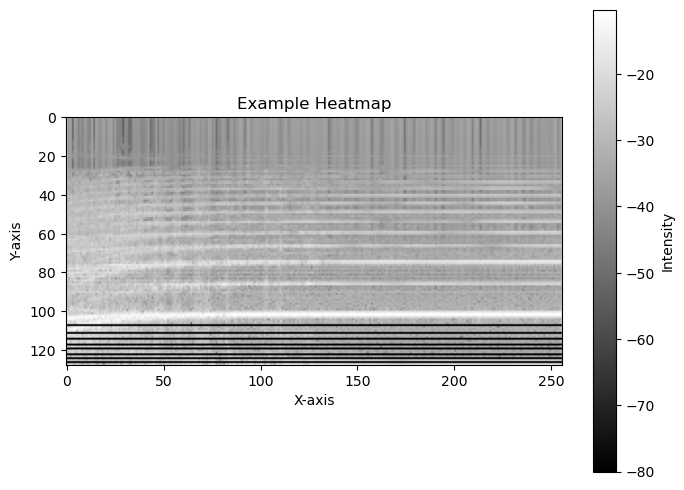

In [5]:
plot_heatmap(test_mels, index=12, cmap='gray', title="Example Heatmap")

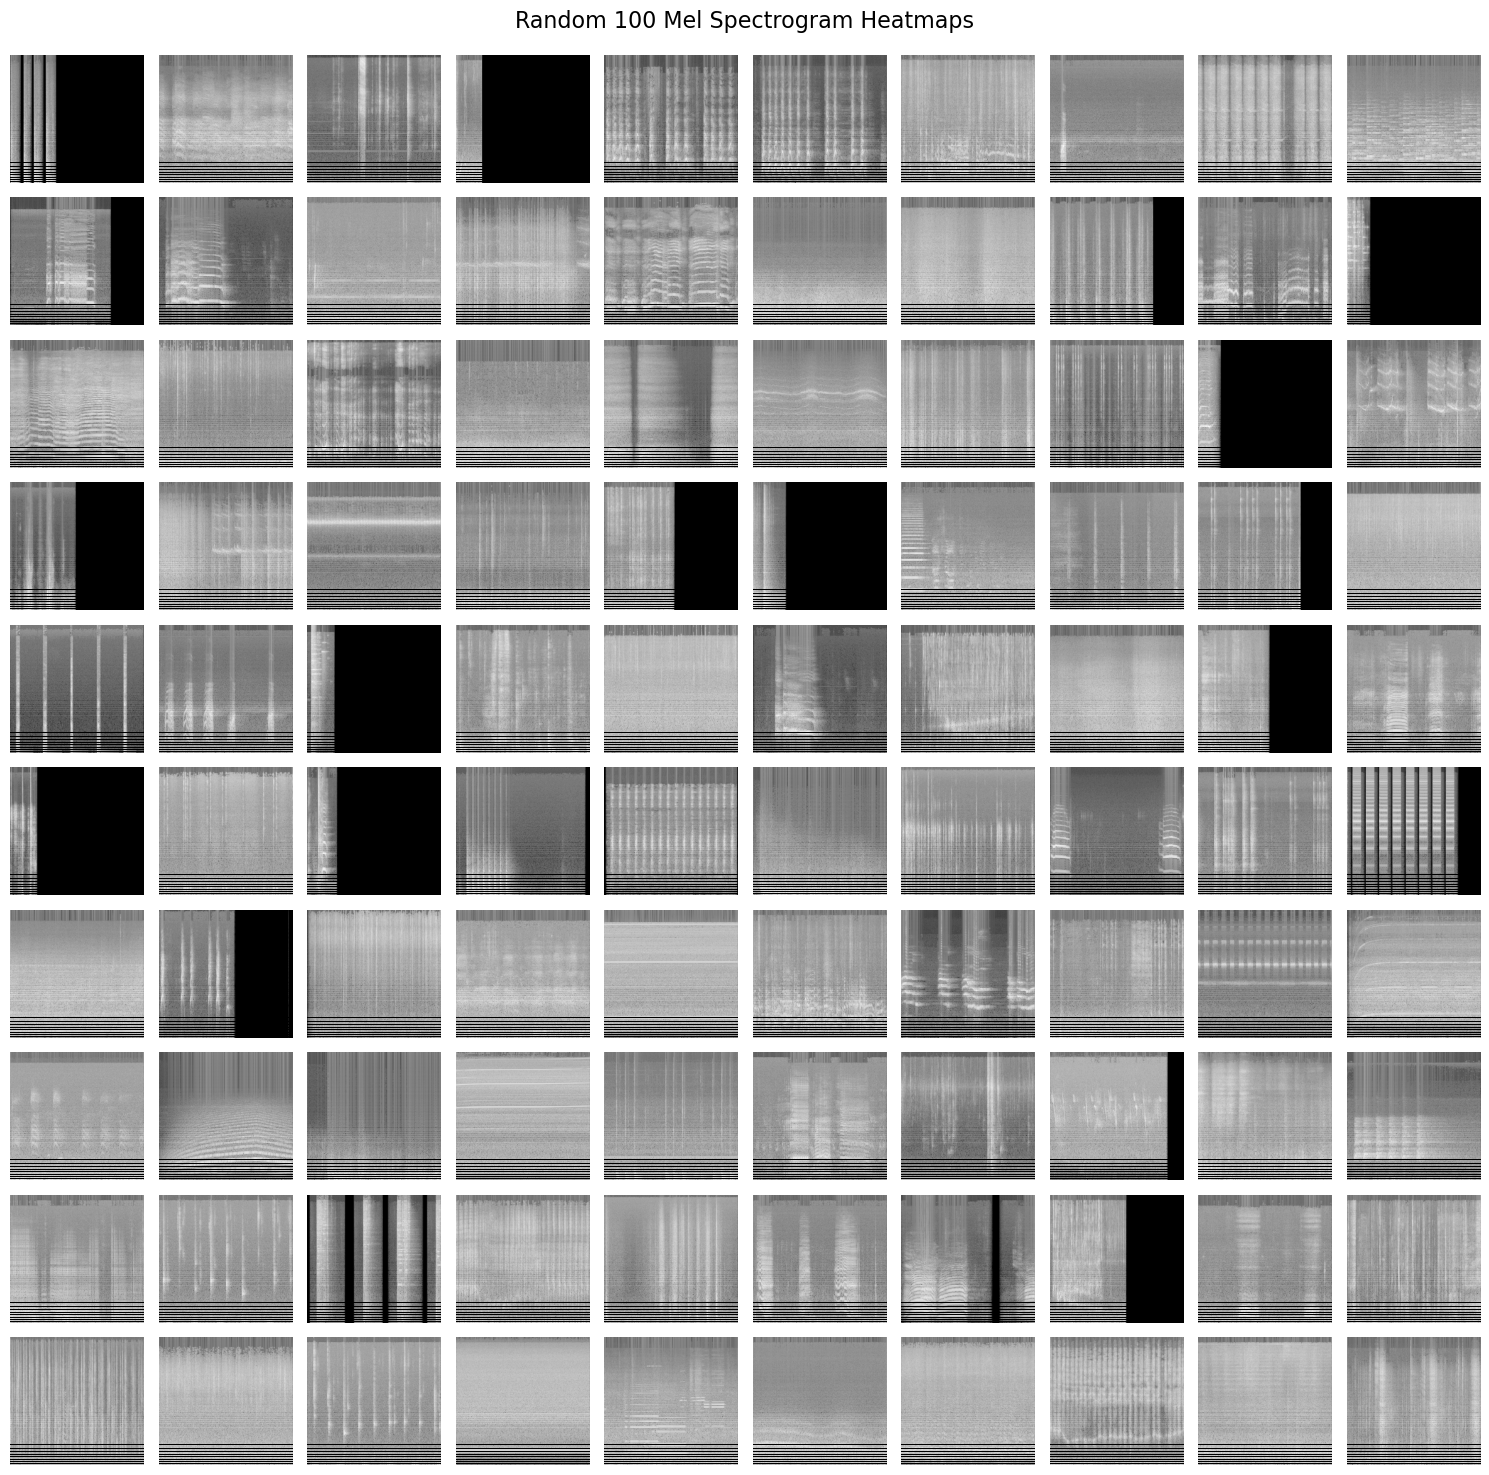

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

print(test_mels.mean(axis=(-1, -2)))

# 随机挑选 100 张
num_samples = 100
random_indices = random.sample(range(len(test_mels)), num_samples)
selected_mels = [test_mels[i] for i in random_indices]

# 设置网格大小（10x10）
rows, cols = 10, 10
fig, axes = plt.subplots(rows, cols, figsize=(15, 15))  # 设置整个画布大小

for i, ax in enumerate(axes.flatten()):
    ax.imshow(selected_mels[i], vmin=-80, vmax=0.0, cmap='gray', aspect='auto')
    ax.axis('off')  # 去掉坐标轴

# 添加标题并显示
plt.suptitle("Random 100 Mel Spectrogram Heatmaps", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)  # 调整标题和图像的间距
plt.show()
